In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# ML -> KNN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

In [116]:
df = pd.read_csv('C:/Users/pinki/OneDrive/Desktop/Machine_learning_indetails/dataset/student.csv')
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,higher education,higher education,at_home,teacher,course,mother,15 to 30 min.,2 to 5 hours,0,yes,no,no,no,yes,yes,no,no,very good,medium,high,very low,very low,good,6,5,6,6
1,GP,F,17,U,GT3,T,primary education (4th grade),primary education (4th grade),at_home,other,course,father,<15 min.,2 to 5 hours,0,no,yes,no,no,no,yes,yes,no,excellent,medium,medium,very low,very low,good,4,5,5,6
2,GP,F,15,U,LE3,T,primary education (4th grade),primary education (4th grade),at_home,other,other,mother,<15 min.,2 to 5 hours,3,yes,no,yes,no,yes,yes,yes,no,very good,medium,low,low,medium,good,10,7,8,10
3,GP,F,15,U,GT3,T,higher education,5th to 9th grade,health,services,home,mother,<15 min.,5 to 10 hours,0,no,yes,yes,yes,yes,yes,yes,yes,good,low,low,very low,very low,excellent,2,15,14,15
4,GP,F,16,U,GT3,T,secondary education,secondary education,other,other,home,father,<15 min.,2 to 5 hours,0,no,yes,yes,no,yes,yes,no,no,very good,medium,low,very low,low,excellent,4,6,10,10


In [117]:
df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

In [118]:
df_sample = df[['Medu', 'Fedu','traveltime', 'studytime', 'failures', 'schoolsup', 'famsup',
    'activities','internet','famrel', 'freetime', 'goout', 'Dalc','Walc', 
    'health', 'absences', 'G1', 'G2', 'G3']]

In [119]:
df = df_sample

In [120]:
df.columns

Index(['Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'schoolsup',
       'famsup', 'activities', 'internet', 'famrel', 'freetime', 'goout',
       'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

In [121]:
columns = ['Medu', 'Fedu', 'traveltime', 'studytime','schoolsup',
       'famsup', 'activities', 'internet', 'famrel', 'freetime', 'goout',
       'Dalc', 'Walc', 'health']
for col in columns:
    print(col)
    print('-'*15)
    unique = df[col].unique()
    print(unique)
    print('-'*30)

Medu
---------------
['higher education' 'primary education (4th grade)' 'secondary education'
 '5th to 9th grade' 'none']
------------------------------
Fedu
---------------
['higher education' 'primary education (4th grade)' '5th to 9th grade'
 'secondary education' 'none']
------------------------------
traveltime
---------------
['15 to 30 min.' '<15 min.' '30 min. to 1 hour' '>1 hour']
------------------------------
studytime
---------------
['2 to 5 hours' '5 to 10 hours' '<2 hours' '>10 hours']
------------------------------
schoolsup
---------------
['yes' 'no']
------------------------------
famsup
---------------
['no' 'yes']
------------------------------
activities
---------------
['no' 'yes']
------------------------------
internet
---------------
['no' 'yes']
------------------------------
famrel
---------------
['very good' 'excellent' 'good' 'very bad' 'bad']
------------------------------
freetime
---------------
['medium' 'low' 'high' 'very low' 'very high']
---------

### Label Encoding

In [122]:
edu = {
    'none': 0,
    'primary education (4th grade)': 1,
    '5th to 9th grade': 2,
    'secondary education': 3,
    'higher education': 4
}
columns = ['Medu', 'Fedu']
for col in columns:
    df[f'{col}_id'] = df[col].map(edu)
    # Direct Replace values in original columns
    #df[col] = df[col].map(edu)

In [123]:
y_n = {
    'no': 0,
    'yes': 1
}
columns = ['schoolsup', 'famsup', 'activities', 'internet']
for col in columns:
     df[f'{col}_id'] = df[col].map(y_n)

In [124]:
val = {
    'very low': 0,
    'low': 1,
    'medium': 2, 
    'high': 3,
    'very high': 4
}
columns = ['freetime', 'goout', 'Dalc', 'Walc']
for col in columns:
     df[f'{col}_id'] = df[col].map(val)

In [125]:
fh = {
    'very bad': 0,
    'bad': 1,
    'good': 2,
    'very good': 3,
    'excellent': 4
}

columns = ['famrel', 'health']
for col in columns:
     df[f'{col}_id'] = df[col].map(fh)

In [126]:
tt = {
    '<15 min.': 0,
    '15 to 30 min.': 1,
    '30 min. to 1 hour': 2,
    '>1 hour': 3
}
df['travel_time_id'] = df['traveltime'].map(tt)

In [127]:
st = {
    '<2 hours': 0,
    '2 to 5 hours': 1,
    '5 to 10 hours': 2,
    '>10 hours': 3
}
df['studytime_id'] = df['studytime'].map(st)

In [128]:
df['G3'].unique()

array([ 6, 10, 15, 11, 19,  9, 12, 14, 16,  5,  8, 17, 18, 13, 20,  7,  0,
        4])

In [129]:
def grade(marks):
    if marks >= 17 and marks <= 20:
        return 'A'
    elif marks >= 14 and marks < 17:
        return 'B'
    elif marks >=10 and marks < 14:
        return 'C'
    elif marks >= 6 and marks < 10:
        return 'D'
    else:
        return 'Fail'

In [130]:
df['Grade'] = df['G3'].apply(grade)

In [131]:
le = LabelEncoder()
df['grade_id'] = le.fit_transform(df['Grade'])

In [132]:
df.columns

Index(['Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'schoolsup',
       'famsup', 'activities', 'internet', 'famrel', 'freetime', 'goout',
       'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3', 'Medu_id',
       'Fedu_id', 'schoolsup_id', 'famsup_id', 'activities_id', 'internet_id',
       'freetime_id', 'goout_id', 'Dalc_id', 'Walc_id', 'famrel_id',
       'health_id', 'travel_time_id', 'studytime_id', 'Grade', 'grade_id'],
      dtype='object')

In [133]:
features = ['Medu_id', 'Fedu_id', 'schoolsup_id', 'famsup_id', 'activities_id', 'internet_id',
            'freetime_id', 'goout_id', 'Dalc_id', 'Walc_id', 'famrel_id', 'health_id', 'travel_time_id', 
            'studytime_id', 'failures', 'absences', 'G1', 'G2']
target = 'grade_id'

In [134]:
X = df[features]
Y = df[target]

In [135]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.3, random_state=42
)

In [136]:
scaler = StandardScaler()
X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.transform(X_test)

### Elbow Method

In [137]:
error_rate = []
k_range = range(1, 21)

In [138]:
for i in k_range:
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train_scale, Y_train)
    knn_pred = knn.predict(X_test_scale)
    error_rate.append(np.mean(Y_test != knn_pred))

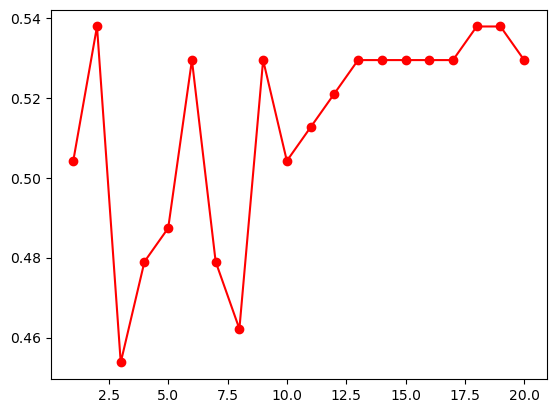

In [139]:
plt.plot(k_range, error_rate, marker='o', color='red')

In [140]:
k=3
model = KNeighborsClassifier(n_neighbors=k)

In [141]:
model.fit(X_train_scale, Y_train)
Y_pred = model.predict(X_test_scale)

In [142]:
cr = classification_report(Y_test, Y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.50      0.33      0.40         9
           1       0.67      0.56      0.61        25
           2       0.52      0.90      0.66        39
           3       0.50      0.30      0.38        30
           4       0.57      0.25      0.35        16

    accuracy                           0.55       119
   macro avg       0.55      0.47      0.48       119
weighted avg       0.55      0.55      0.52       119



### New Data Prediction

In [143]:
input_data = {
    'Medu_id': [1, 3, 4], 
    'Fedu_id': [0, 4, 4], 
    'schoolsup_id': [1, 1, 1], 
    'famsup_id': [0, 1, 1], 
    'activities_id': [1, 1, 1], 
    'internet_id': [0, 1, 1],
    'freetime_id': [1, 1, 1], 
    'goout_id': [4, 4, 0], 
    'Dalc_id': [4, 4, 0], 
    'Walc_id': [0, 0, 0], 
    'famrel_id': [4, 2, 1], 
    'health_id': [4, 4, 4], 
    'travel_time_id': [0, 1, 3], 
    'studytime_id': [0, 1, 1], 
    'failures': [0, 1, 3], 
    'absences': [2, 4, 0], 
    'G1': [7, 8, 10], 
    'G2': [10, 5, 18]
}

In [144]:
X_new = pd.DataFrame(input_data)

In [145]:
X_new_scale = scaler.transform(X_new)

In [146]:
new_pred = model.predict(X_new_scale)

In [147]:
X_new['predicted_grade'] = new_pred

In [148]:
X_new

,Medu_id,Fedu_id,schoolsup_id,famsup_id,activities_id,internet_id,freetime_id,goout_id,Dalc_id,Walc_id,famrel_id,health_id,travel_time_id,studytime_id,failures,absences,G1,G2,predicted_grade
0,1,0,1,0,1,0,1,4,4,0,4,4,0,0,0,2,7,10,1
1,3,4,1,1,1,1,1,4,4,0,2,4,1,1,1,4,8,5,2
2,4,4,1,1,1,1,1,0,0,0,1,4,3,1,3,0,10,18,2


# SVM model trained

In [149]:
from sklearn.svm import SVC


In [150]:
model = SVC(kernel='linear') 

In [151]:

model.fit(X_train_scale, Y_train)
svc_pred = model.predict(X_test_scale)

In [152]:
cr = classification_report(Y_test, svc_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.78      0.78      0.78         9
           1       0.86      0.76      0.81        25
           2       0.73      0.77      0.75        39
           3       0.62      0.77      0.69        30
           4       0.50      0.31      0.38        16

    accuracy                           0.71       119
   macro avg       0.70      0.68      0.68       119
weighted avg       0.70      0.71      0.70       119



# random forest trained

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [154]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

In [155]:
rf_model.fit(X_train_scale, Y_train)
rf_pred = rf_model.predict(X_test_scale)

In [160]:
cr = classification_report(Y_test, Y_pred)
cm = confusion_matrix(Y_test, Y_pred)

In [157]:
print(cr)

              precision    recall  f1-score   support

           0       0.50      0.33      0.40         9
           1       0.67      0.56      0.61        25
           2       0.52      0.90      0.66        39
           3       0.50      0.30      0.38        30
           4       0.57      0.25      0.35        16

    accuracy                           0.55       119
   macro avg       0.55      0.47      0.48       119
weighted avg       0.55      0.55      0.52       119



In [ ]:
print(cm)


[[ 3  5  1  0  0]
 [ 3 14  8  0  0]
 [ 0  2 35  2  0]
 [ 0  0 18  9  3]
 [ 0  0  5  7  4]]


# XGboost model trained

In [ ]:
from sklearn.metrics import classification_report